In [49]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.gridspec as gridspec
import numpy as np
import importlib
import os
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
from matplotlib.patches import Ellipse

#import utils
from utils import analysis, plot, metadata

importlib.reload(analysis)
importlib.reload(plot)
importlib.reload(metadata)

<module 'utils.metadata' from '/Users/snewbank/PycharmProjects/MARIPoSA/utils/metadata.py'>

In [52]:
importlib.reload(analysis)
importlib.reload(plot)

config_path="/Users/snewbank/Behavior/MARIPOSA_test/240904_VAME-full/config_PS.yaml"
save_path="/Users/snewbank/Behavior/MARIPOSA_test/240904_VAME-full/demo_alldrugs/"
save=True

#Load config
config = metadata.load_project(config_path)

Features selected by f-stat were: module7_t0-60, module1_t60-120, module8_t60-120, module9_t60-120, module10_t60-120, module12_t60-120, module1_t120-180, module3_t120-180, module6_t120-180, module8_t120-180, module12_t120-180, module11_t180-240, module12_t180-240, module14_t180-240, module9_t240-300, module14_t240-300, module14_t300-360, module2_t360-420, module5_t360-420, module9_t360-420, module11_t360-420, module13_t360-420, module11_t420-480, module13_t420-480, module14_t420-480, module8_t480-540, module9_t480-540, module2_t540-600, module8_t540-600, module9_t540-600, module10_t540-600, module2_t600-660, module6_t600-660, module8_t600-660, module9_t600-660, module10_t600-660, module14_t600-660, module5_t660-720, module8_t660-720, module9_t660-720, module10_t660-720, module13_t660-720, module14_t660-720, module2_t720-780, module5_t720-780, module7_t720-780, module9_t720-780, module10_t720-780, module14_t720-780, module2_t780-840, module5_t780-840, module8_t780-840, module9_t780-840,

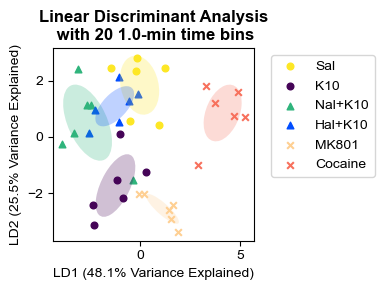

0.6666666666666666


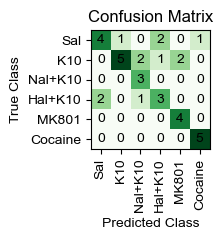

In [53]:
selected_subgroups=['salip', 'k10ip', 'nalket', 'halket', 'mk801', 'cocaine']
vir = plt.get_cmap("viridis_r")
jet = plt.get_cmap("jet")
mag = plt.get_cmap("magma")

color_dict = {'salip': vir([0]), 'k1ip': vir([0.33]), 'k5ip': vir([0.667]), 'k10ip': vir([0.99]), 
          'nalket': vir([0.35]), 'halket': jet([0.2]), 'mk801': mag([0.9]), 'cocaine': mag([0.7])}

marker_dict = {'salip': "o", 'k1ip': "o", 'k5ip': "o", 'k10ip': "o", 
          'nalket': "^", 'halket': "^", 'mk801': "x", 'cocaine': "x"}

alt_labels = {'salip': "Sal", 'k1ip': "K1", 'k5ip': "K5", 'k10ip': "K10", 
          'nalket': "Nal+K10", 'halket': "Hal+K10", 'mk801': "MK801", 'cocaine': "Cocaine"}

labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=selected_subgroups)
lda_result = analysis.lda_labels_timebins(config,labels_df,binsize=60,selected_subgroups=selected_subgroups,loocv=True,feature_selection=("f",100),
                                          ncomponents=2)
fig = plot.plot_lda(config, lda_result, cmap=color_dict, marker_dict=marker_dict,draw_ellipse=True,alt_labels=alt_labels)
if save==True:
    plt.savefig(save_path+"lda_diffdrugs.png",dpi=500)

plt.show()

fig = plot.plot_conf_mat(lda_result,rotate_xticks=True,alt_labels=alt_labels)
if save==True:
    plt.savefig(save_path+"loocv_diffdrugs.png",dpi=500)
print(lda_result.loocv_accuracy)

0.6666666666666666
done with ['2023-07-18_18-19-50_bm04_k10iv_2023-07-18_18-19-50_bm04_k10iv.csv', '2023-07-18_18-19-50_bm04_k10iv']
done with ['2023-06-20_19-10-38_bf04_k1iv_2023-06-20_19-10-38_bf04_k1iv.csv', '2023-06-20_19-10-38_bf04_k1iv']
VAME modules map onto scored behaviors with 'loss' of 0.3304357516995431
done with ['2023-07-18_18-19-50_bm04_k10iv_2023-07-18_18-19-50_bm04_k10iv.csv', '2023-07-18_18-19-50_bm04_k10iv']
done with ['2023-06-20_19-10-38_bf04_k1iv_2023-06-20_19-10-38_bf04_k1iv.csv', '2023-06-20_19-10-38_bf04_k1iv']
VAME modules map onto scored behaviors with 'loss' of 0.3304357516995431


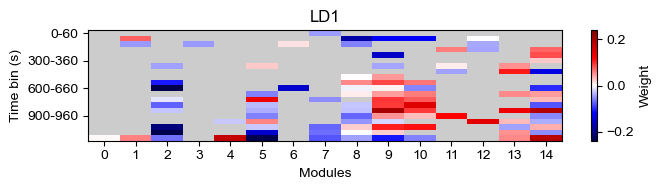

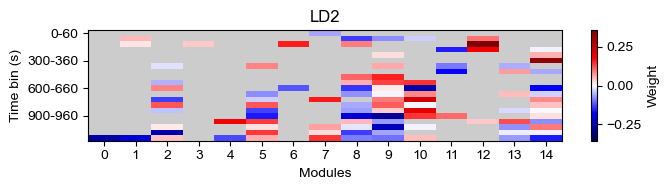

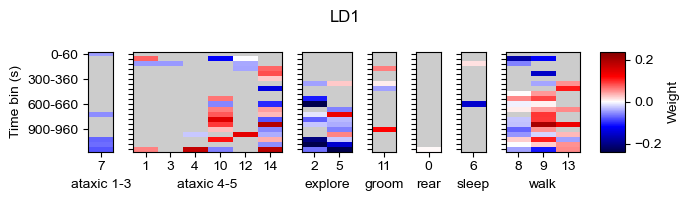

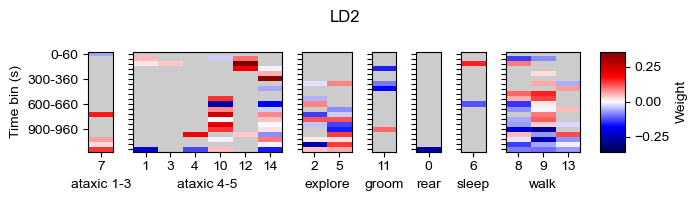

In [55]:
figW=7
figH=2

figs = plot.plot_lda_weights(config, lda_result,n_modules,hide_nofeat_mods=False,remap=False,figW=figW,figH=figH)
if save==True:
    figs[0].savefig(save_path+"ld1.png",dpi=500)
    figs[1].savefig(save_path+"ld2.png",dpi=500)
print(lda_result.loocv_accuracy)
figs = plot.plot_lda_weights(config, lda_result, n_modules, hide_nofeat_mods=True, remap=True,figW=figW,figH=figH)
if save == True:
    figs[0].savefig(save_path + "ld1_remapped.png", dpi=500)
    figs[1].savefig(save_path + "ld2_remapped.png", dpi=500)